**Loading and merging the cleaned dataset**

In [11]:
import pandas as pd

# load
activity = pd.read_csv(r"C:\Users\Affan\Desktop\DAL_Mini_Project\Data\Selected_Data\dailyActivity_merged.csv")
sleep = pd.read_csv(r"C:\Users\Affan\Desktop\DAL_Mini_Project\Data\Selected_Data\sleepDay_merged.csv")

# fix dates
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate'], format='mixed').dt.date
sleep['ActivityDate'] = pd.to_datetime(sleep['ActivityDate'], format='mixed').dt.date

df = pd.merge(activity, sleep, on=["Id", "ActivityDate"], how="left")

display(df.head())
display(df.shape)

,Id,ActivityDate,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepMinutes
0,1503960366,2016-04-12,13162,25,13,328,728,1985,327.0
1,1503960366,2016-04-13,10735,21,19,217,776,1797,384.0
2,1503960366,2016-04-14,10460,30,11,181,1218,1776,NaN
3,1503960366,2016-04-15,9762,29,34,209,726,1745,412.0
4,1503960366,2016-04-16,12669,36,10,221,773,1863,340.0


(943, 9)

**Data Preprocessing**

In [13]:
# DATA PREPROCESSING PIPELINE

import pandas as pd

# 1. Handle missing values
df['SleepMinutes'] = df['SleepMinutes'].fillna(0)

# 2. Remove duplicates (if any)
df = df.drop_duplicates()

# 3. Remove invalid rows (basic sanity)
df = df[df['TotalSteps'] >= 0]
df = df[df['Calories'] > 0]

# 4. Feature Engineering
df['TotalActiveMinutes'] = (
df['VeryActiveMinutes'] +
df['FairlyActiveMinutes'] +
df['LightlyActiveMinutes']
)

# 5. Optional: Activity Ratio (useful for clustering)
df['ActivityRatio'] = df['TotalActiveMinutes'] / (df['SedentaryMinutes'] + 1)

# 6. Convert date to datetime (for sorting if needed)
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])

# 7. Sort data (clean structure)
df = df.sort_values(by=['Id', 'ActivityDate'])

# 8. Reset index
df = df.reset_index(drop=True)

# FINAL CHECK
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    936 non-null    int64         
 1   ActivityDate          936 non-null    datetime64[ns]
 2   TotalSteps            936 non-null    int64         
 3   VeryActiveMinutes     936 non-null    int64         
 4   FairlyActiveMinutes   936 non-null    int64         
 5   LightlyActiveMinutes  936 non-null    int64         
 6   SedentaryMinutes      936 non-null    int64         
 7   Calories              936 non-null    int64         
 8   SleepMinutes          936 non-null    float64       
 9   TotalActiveMinutes    936 non-null    int64         
 10  ActivityRatio         936 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(8)
memory usage: 80.6 KB
None
                 Id                   ActivityDate    TotalSteps  

**EXPERIMENT 1**

Q1 (25th percentile): 1834.0
Q2 (Median): 2144.0
Q3 (75th percentile): 2794.5
IQR: 960.5
Lower Bound: 393.25
Upper Bound: 4235.25
Outliers: [  52  257 4274 4552 4392 4501 4546 4900  120 4236   57 4547 4398]


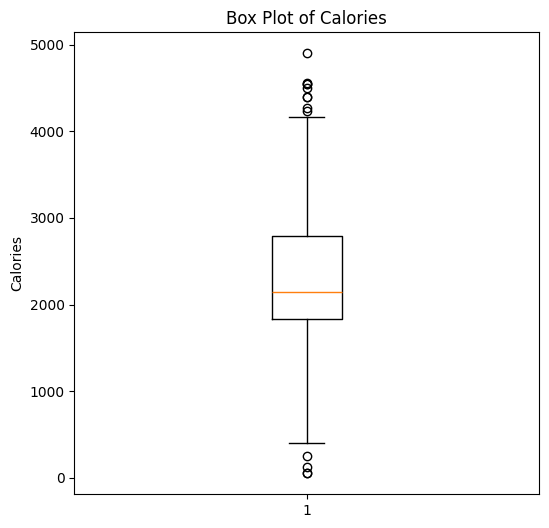

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Select column (use Calories for your dataset)
data = df['Calories']

# Sort data
data_sorted = data.sort_values()

# Calculate quartiles
Q1 = data.quantile(0.25)
Q2 = data.median()
Q3 = data.quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q2 (Median): {Q2}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Identify outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]
print("Outliers:", outliers.values)

# Plot box plot
plt.figure(figsize=(6,6))
plt.boxplot(data, vert=True)

plt.title("Box Plot of Calories")
plt.ylabel("Calories")

plt.show()


**EXPERIMENT 2**

Intercept: 1679.1193587644516
Slope: 2.710262706508285
R² Score: 0.14864128944936228
MSE: 430068.97851552843


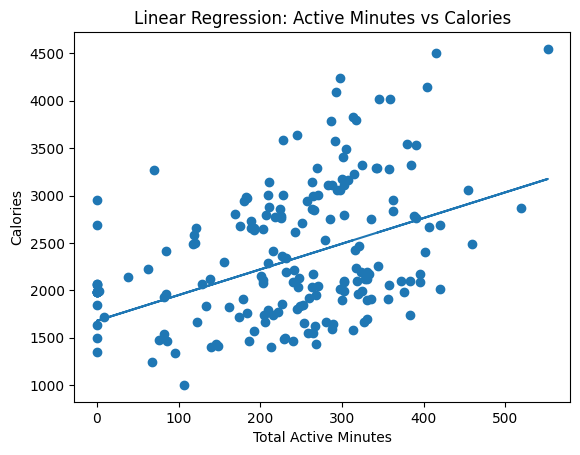

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Features (X) and Target (y)
X = df[['TotalActiveMinutes']]
y = df['Calories']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Intercept: {model.intercept_}")
print(f"Slope: {model.coef_[0]}")
print(f"R² Score: {r2}")
print(f"MSE: {mse}")

# Plot
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)

plt.xlabel("Total Active Minutes")
plt.ylabel("Calories")
plt.title("Linear Regression: Active Minutes vs Calories")

plt.show()


**EXPERIMENT 3**

In [17]:
import numpy as np

# 1. Population
population = df.copy()
population_size = len(population)

print("Population Size:", population_size)


# 2. Simple Random Sampling
simple_sample = population.sample(n=50, random_state=42)


# 3. Systematic Sampling
k = population_size // 50
systematic_sample = population.iloc[::k].head(50)


# 4. Stratified Sampling

# Create strata using activity levels
population['ActivityLevel'] = pd.qcut(population['TotalActiveMinutes'], q=3, labels=["Low", "Medium", "High"])

stratified_sample = population.groupby('ActivityLevel', group_keys=False).apply(lambda x: x.sample(15, random_state=42))


# 5. Cluster Sampling

# Treat Id as cluster (users)
random_cluster = np.random.choice(population['Id'].unique())
cluster_sample = population[population['Id'] == random_cluster]


# 6. Compare Means
print("\n--- Mean Calories Comparison ---")
print("Population Mean:", population['Calories'].mean())
print("Simple Random Mean:", simple_sample['Calories'].mean())
print("Systematic Mean:", systematic_sample['Calories'].mean())
print("Stratified Mean:", stratified_sample['Calories'].mean())
print("Cluster Mean:", cluster_sample['Calories'].mean())


Population Size: 936

--- Mean Calories Comparison ---
Population Mean: 2313.45405982906
Simple Random Mean: 2315.32
Systematic Mean: 2321.0
Stratified Mean: 2201.4222222222224
Cluster Mean: 1876.9666666666667


C:\Users\Affan\AppData\Local\Temp\ipykernel_24488\1207260803.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stratified_sample = population.groupby('ActivityLevel', group_keys=False).apply(lambda x: x.sample(15, random_state=42))
C:\Users\Affan\AppData\Local\Temp\ipykernel_24488\1207260803.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = population.groupby('ActivityLevel', group_keys=False).apply(lambda x: x.sample(15, random_state=42))


**EXPERIMENT 4**

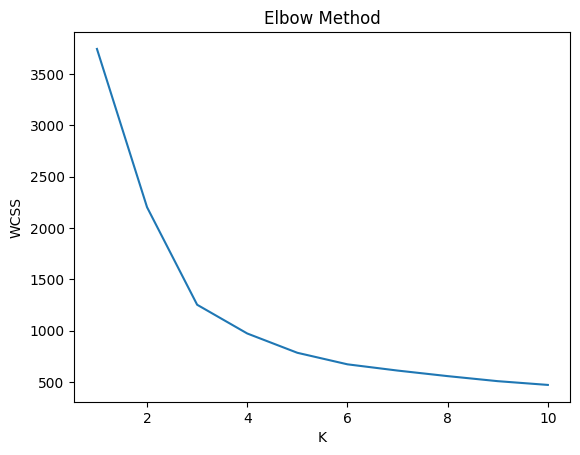

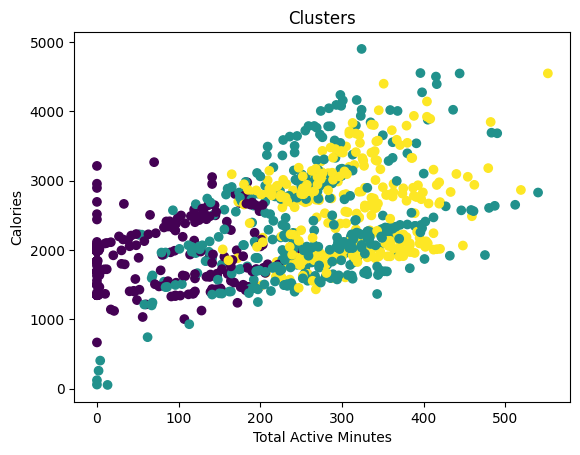

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# features
X = df[['TotalSteps', 'TotalActiveMinutes', 'SedentaryMinutes', 'SleepMinutes']]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# elbow method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# final model (use K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# visualize (2D)
plt.scatter(df['TotalActiveMinutes'], df['Calories'], c=df['Cluster'])
plt.xlabel("Total Active Minutes")
plt.ylabel("Calories")
plt.title("Clusters")
plt.show()

**EXPERIMENT 5**

Mean: 2313.45405982906
Std Dev: 703.6838741073205


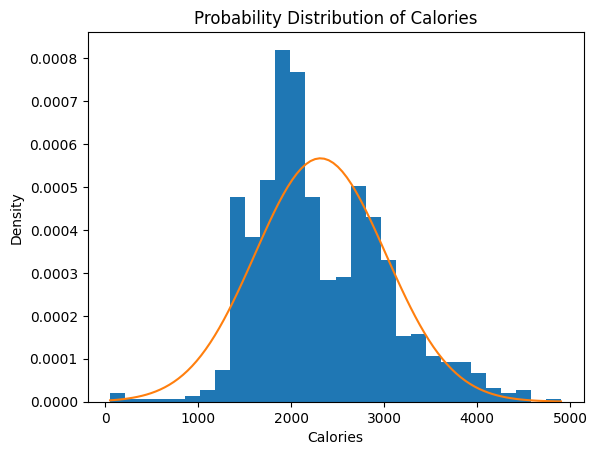

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# random variable
X = df['Calories']

# mean and std
mean = X.mean()
std = X.std()

print("Mean:", mean)
print("Std Dev:", std)

# generate PDF
x_values = np.linspace(X.min(), X.max(), 100)
pdf_values = norm.pdf(x_values, mean, std)

# plot
plt.hist(X, bins=30, density=True)
plt.plot(x_values, pdf_values)

plt.xlabel("Calories")
plt.ylabel("Density")
plt.title("Probability Distribution of Calories")

plt.show()

**EXPERIMENT 6**

Mean: 2313.45405982906
Variance: 494641.9658382186
Standard Deviation: 703.3078741477437
Skewness: 0.5584494162900877
Kurtosis: 0.41478388609291317


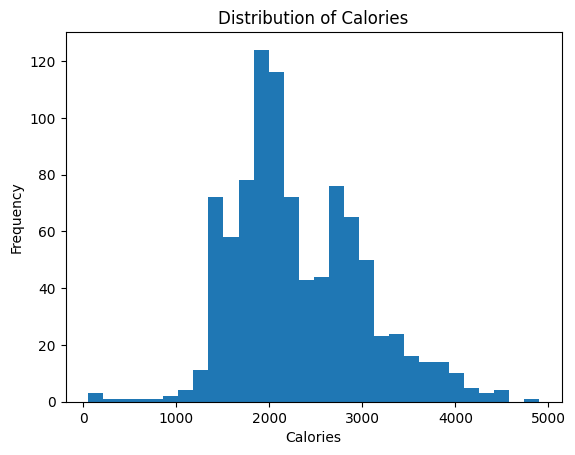

In [20]:
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

# use Calories
data = df['Calories']

# stats
mean = np.mean(data)
variance = np.var(data)
std_dev = np.std(data)
skewness = skew(data)
kurt = kurtosis(data)

print("Mean:", mean)
print("Variance:", variance)
print("Standard Deviation:", std_dev)
print("Skewness:", skewness)
print("Kurtosis:", kurt)

# plot
plt.hist(data, bins=30)
plt.title("Distribution of Calories")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()